# Lab 5: EEG Motor Imagery Classification

The goal of this laboratory work is to classify EEG signals related to motor imagery.  
The task is to distinguish between two cognitive states: imagined movement of the left fist and imagined movement of the right fist.

The solution includes:
- loading EEG datasets;
- exploring the signal structure;
- transforming one-dimensional EEG signals into time-frequency images using Wavelet Transform;
- training a neural network classifier.

In [73]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import pywt

In [74]:
DATA_DIR = Path("data")

train_data_path = DATA_DIR / "MI-EEG-B9T.csv"
test_data_path = DATA_DIR / "MI-EEG-B9E.csv"

train_target_path = DATA_DIR / "2class_MI_EEG_train_9.csv"
test_target_path = DATA_DIR / "2class_MI_EEG_test_9.csv"

files = [
    train_data_path,
    test_data_path,
    train_target_path,
    test_target_path
]

for file in files:
    print(f"{file}: exists = {file.exists()}")

data\MI-EEG-B9T.csv: exists = True
data\MI-EEG-B9E.csv: exists = True
data\2class_MI_EEG_train_9.csv: exists = True
data\2class_MI_EEG_test_9.csv: exists = True


In [75]:
X_train_raw = pd.read_csv(train_data_path, header=None)
X_test_raw = pd.read_csv(test_data_path, header=None)

y_train_raw = pd.read_csv(train_target_path, header=None)
y_test_raw = pd.read_csv(test_target_path, header=None)

print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
print("y_train shape:", y_train_raw.shape)
print("y_test shape:", y_test_raw.shape)

X_train shape: (400, 3000)
X_test shape: (320, 3000)
y_train shape: (400, 1)
y_test shape: (320, 1)


In [76]:
X_train = X_train_raw.values.astype(np.float32)
X_test = X_test_raw.values.astype(np.float32)

y_train = y_train_raw.values.ravel()
y_test = y_test_raw.values.ravel()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

X_train: (400, 3000)
X_test: (320, 3000)
y_train: (400,)
y_test: (320,)
Train labels: (array([0, 1], dtype=int64), array([200, 200], dtype=int64))
Test labels: (array([0, 1], dtype=int64), array([160, 160], dtype=int64))


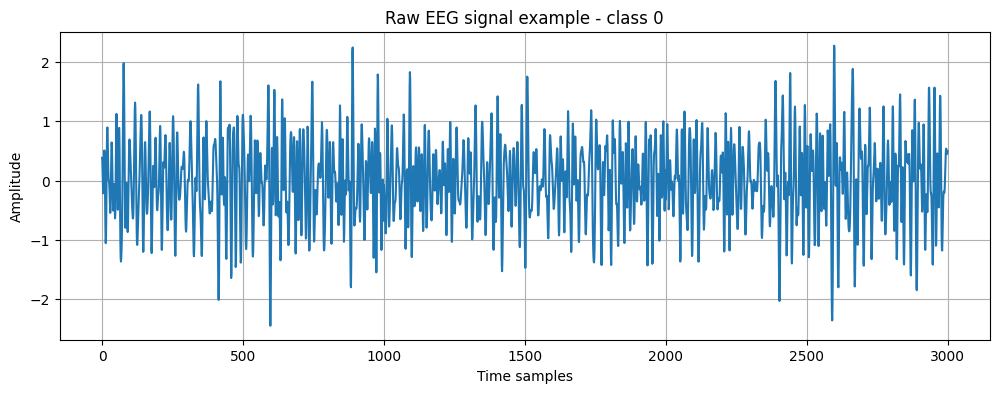

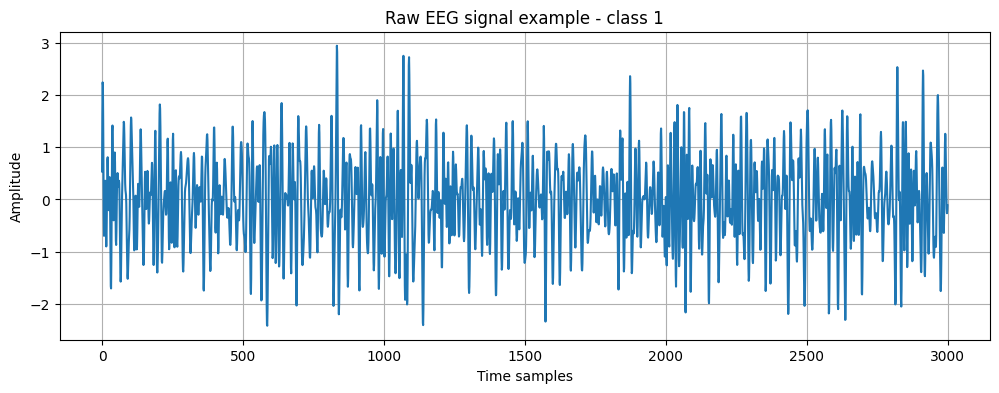

In [77]:
def plot_signal(signal, title):
    plt.figure(figsize=(12, 4))
    plt.plot(signal)
    plt.title(title)
    plt.xlabel("Time samples")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


first_label = np.unique(y_train)[0]
second_label = np.unique(y_train)[1]

idx_first = np.where(y_train == first_label)[0][0]
idx_second = np.where(y_train == second_label)[0][0]

plot_signal(X_train[idx_first], f"Raw EEG signal example - class {first_label}")
plot_signal(X_train[idx_second], f"Raw EEG signal example - class {second_label}")

In [78]:
def wavelet_transform(signal, scales=np.arange(1, 65), wavelet="morl", downsample_factor=10):
    """
    Convert a 1D EEG signal into a 2D time-frequency image using Continuous Wavelet Transform.
    """
    coefficients, frequencies = pywt.cwt(signal, scales, wavelet)

    scalogram = np.abs(coefficients)
    scalogram = np.log1p(scalogram)

    n_scales, n_time = scalogram.shape
    new_time = n_time // downsample_factor

    scalogram = scalogram[:, :new_time * downsample_factor]
    scalogram = scalogram.reshape(n_scales, new_time, downsample_factor).mean(axis=2)

    return scalogram.astype(np.float32)

Wavelet image shape: (64, 300)


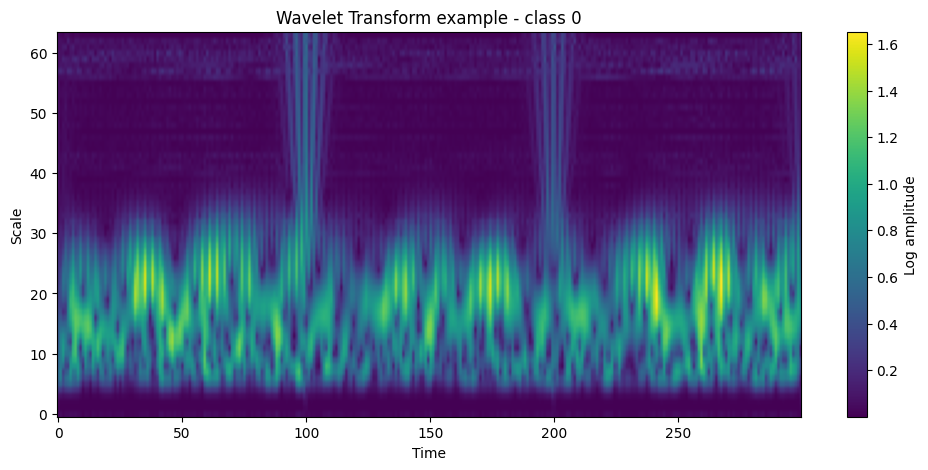

In [79]:
example_signal = X_train[idx_first]
example_wavelet = wavelet_transform(example_signal)

print("Wavelet image shape:", example_wavelet.shape)

plt.figure(figsize=(12, 5))
plt.imshow(
    example_wavelet,
    aspect="auto",
    origin="lower"
)
plt.title(f"Wavelet Transform example - class {first_label}")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.colorbar(label="Log amplitude")
plt.show()

In [80]:
def transform_dataset_to_wavelets(X):
    """
    Apply Wavelet Transform to all EEG signals.
    """
    images = []

    for i, signal in enumerate(X):
        image = wavelet_transform(signal)
        images.append(image)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(X)} signals")

    return np.array(images, dtype=np.float32)


X_train_wav = transform_dataset_to_wavelets(X_train)
X_test_wav = transform_dataset_to_wavelets(X_test)

print("X_train_wav shape:", X_train_wav.shape)
print("X_test_wav shape:", X_test_wav.shape)

Processed 50/400 signals
Processed 100/400 signals
Processed 150/400 signals
Processed 200/400 signals
Processed 250/400 signals
Processed 300/400 signals
Processed 350/400 signals
Processed 400/400 signals
Processed 50/320 signals
Processed 100/320 signals
Processed 150/320 signals
Processed 200/320 signals
Processed 250/320 signals
Processed 300/320 signals
X_train_wav shape: (400, 64, 300)
X_test_wav shape: (320, 64, 300)


In [81]:
mean_value = X_train_wav.mean()
std_value = X_train_wav.std()

X_train_wav = (X_train_wav - mean_value) / std_value
X_test_wav = (X_test_wav - mean_value) / std_value

X_train_cnn = X_train_wav[..., np.newaxis]
X_test_cnn = X_test_wav[..., np.newaxis]

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)

X_train_cnn shape: (400, 64, 300, 1)
X_test_cnn shape: (320, 64, 300, 1)


In [82]:
import copy

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.5.1+cu121
Device: cuda


In [83]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_wav,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

X_tr_t = torch.tensor(X_tr[:, np.newaxis, :, :], dtype=torch.float32)
X_val_t = torch.tensor(X_val[:, np.newaxis, :, :], dtype=torch.float32)
X_test_t = torch.tensor(X_test_wav[:, np.newaxis, :, :], dtype=torch.float32)

y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("X_tr_t:", X_tr_t.shape)
print("X_val_t:", X_val_t.shape)
print("X_test_t:", X_test_t.shape)
print("Train labels:", torch.unique(y_tr_t, return_counts=True))
print("Val labels:", torch.unique(y_val_t, return_counts=True))
print("Test labels:", torch.unique(y_test_t, return_counts=True))

X_tr_t: torch.Size([320, 1, 64, 300])
X_val_t: torch.Size([80, 1, 64, 300])
X_test_t: torch.Size([320, 1, 64, 300])
Train labels: (tensor([0, 1]), tensor([160, 160]))
Val labels: (tensor([0, 1]), tensor([40, 40]))
Test labels: (tensor([0, 1]), tensor([160, 160]))


In [84]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False
)

In [85]:
class StableWaveletCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.AdaptiveAvgPool2d((4, 8))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 8, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = StableWaveletCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=0.001
)

print(model)

StableWaveletCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.2, inplace=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 8))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [86]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

In [87]:
num_epochs = 100
patience = 20

train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    val_loss, val_accuracy, val_preds, val_labels = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    unique_preds, counts_preds = np.unique(val_preds, return_counts=True)

    print(
        f"Epoch {epoch + 1:03d}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val pred dist: {dict(zip(unique_preds, counts_preds))}"
    )

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_model_state)
print("Best validation loss:", best_val_loss)

Epoch 001/100 | Train loss: 0.6958 | Val loss: 0.6932 | Val acc: 0.5000 | Val pred dist: {1: 80}
Epoch 002/100 | Train loss: 0.6927 | Val loss: 0.6929 | Val acc: 0.5000 | Val pred dist: {0: 80}
Epoch 003/100 | Train loss: 0.6932 | Val loss: 0.6929 | Val acc: 0.5125 | Val pred dist: {0: 75, 1: 5}
Epoch 004/100 | Train loss: 0.6936 | Val loss: 0.6929 | Val acc: 0.4875 | Val pred dist: {0: 1, 1: 79}
Epoch 005/100 | Train loss: 0.6930 | Val loss: 0.6928 | Val acc: 0.5000 | Val pred dist: {0: 80}
Epoch 006/100 | Train loss: 0.6923 | Val loss: 0.6930 | Val acc: 0.5000 | Val pred dist: {1: 80}
Epoch 007/100 | Train loss: 0.6928 | Val loss: 0.6926 | Val acc: 0.5000 | Val pred dist: {0: 80}
Epoch 008/100 | Train loss: 0.6931 | Val loss: 0.6924 | Val acc: 0.5000 | Val pred dist: {0: 80}
Epoch 009/100 | Train loss: 0.6929 | Val loss: 0.6923 | Val acc: 0.5000 | Val pred dist: {0: 80}
Epoch 010/100 | Train loss: 0.6934 | Val loss: 0.6924 | Val acc: 0.5125 | Val pred dist: {0: 1, 1: 79}
Epoch 011/10

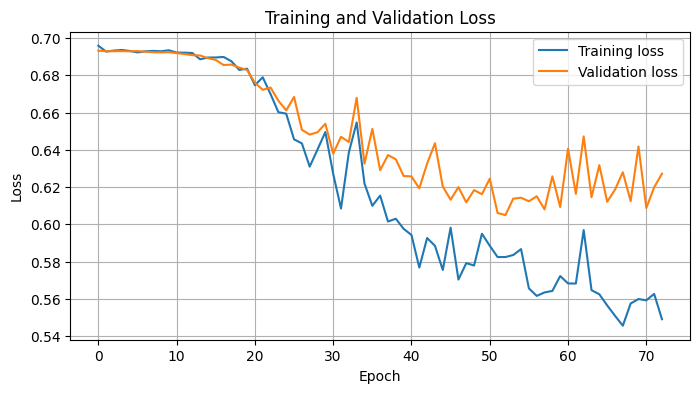

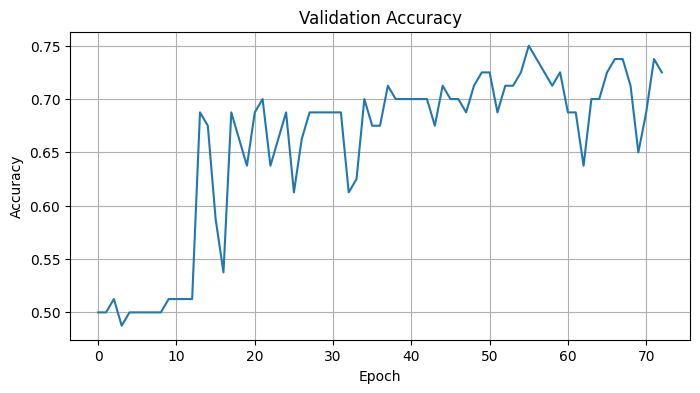

In [88]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [89]:
test_loss, test_accuracy, test_preds, test_labels = evaluate(model, test_loader, criterion)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

print("Test prediction distribution:")
print(np.unique(test_preds, return_counts=True))

print(classification_report(test_labels, test_preds, zero_division=0))

Test loss: 0.5277
Test accuracy: 0.7531
Test prediction distribution:
(array([0, 1], dtype=int64), array([201, 119], dtype=int64))
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       160
           1       0.84      0.62      0.72       160

    accuracy                           0.75       320
   macro avg       0.77      0.75      0.75       320
weighted avg       0.77      0.75      0.75       320



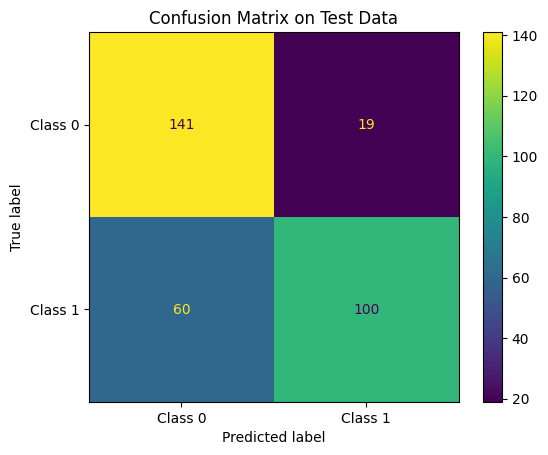

In [90]:
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Confusion Matrix on Test Data")
plt.show()

## Conclusion

In this laboratory work, EEG motor imagery signals were classified into two classes corresponding to imagined movement of the left or right fist.

The original one-dimensional EEG signals were transformed into two-dimensional time-frequency representations using the Continuous Wavelet Transform. These wavelet images were then used as input for a convolutional neural network implemented in PyTorch.

The final CNN model achieved a test accuracy of approximately 75.3%. The confusion matrix and classification report show that the model learned meaningful differences between the two EEG classes, although the recall for the two classes was not perfectly balanced.

The obtained results demonstrate that wavelet-based time-frequency representation combined with a neural network can be used for EEG motor imagery classification.